# Advanced ResNet + LSTM Deepfake Detection Model

## Enhanced Architecture with Higher Complexity

### Key Features:
- **ResNet50 CNN** for deep feature extraction (more complex than ResNet18)
- **Multi-layer Bidirectional LSTM** for temporal modeling
- **Multi-head Attention Mechanism** for better focus
- **Deeper Classifier Network** with residual connections
- **Advanced Training**: Mixed precision, gradient clipping, cosine annealing
- **Video Tracking**: Saves which 100 videos are used for transfer learning later
- **Target**: >90% accuracy with better generalization

### Architecture Overview:
```
Input Frames → ResNet50 Features → Multi-Layer BiLSTM → Multi-Head Attention → Deep Classifier → Output
```

## 1. Imports and Setup

In [1]:
# Core libraries
import os
import json
import numpy as np
import pandas as pd
import random
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
import torchvision.transforms as transforms

# Video processing
import cv2
import mediapipe as mp

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

/home/nibiru/miniconda3/envs/quantum-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
CUDA Version: 12.9
Available GPU Memory: 8.18 GB


## 2. Configuration

In [2]:
# Configuration
CONFIG = {
    # Data paths
    'real_videos_dir': '/home/nibiru/Documents/projects/cv-ai/archive/Celeb-real',
    'fake_videos_dir': '/home/nibiru/Documents/projects/cv-ai/archive/Celeb-synthesis',
    'model_save_dir': '/home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM',
    'used_videos_tracker': '/home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/used_videos.json',
    
    # Data parameters - Optimized for 8GB VRAM
    'num_videos_per_class': 100,  # Start with 100 videos per class
    'train_split': 0.8,
    'sequence_length': 10,  # Longer sequences for better temporal modeling
    'img_size': 224,  # Full resolution for ResNet50
    'max_frames_per_video': 40,
    'frame_skip': 2,
    
    # Temporal features - NEW!
    'use_optical_flow': True,  # Add optical flow features
    'use_frame_diff': True,    # Add frame difference features
    'temporal_fusion': 'concat',  # How to combine: 'concat', 'add', 'attention'
    
    # Model architecture - MORE COMPLEX with Anti-Overfitting
    'resnet_model': 'resnet50',  # ResNet50 for deeper features
    'cnn_feature_size': 2048,  # ResNet50 output features
    'lstm_hidden_size': 512,  # Larger LSTM
    'lstm_num_layers': 3,  # Increased to 3 layers for more complexity
    'lstm_dropout': 0.4,  # Increased dropout in LSTM
    'attention_heads': 8,  # More attention heads
    'attention_size': 512,  # Larger attention dimension
    'fc_hidden_sizes': [1024, 512, 256, 128],  # Deeper classifier with gradual reduction
    'fc_dropout': 0.6,  # Higher dropout to prevent overfitting
    'use_residual': True,  # Residual connections in classifier
    'use_layer_norm': True,  # Layer normalization for stability
    'label_smoothing': 0.1,  # Label smoothing to prevent overconfidence
    
    # Training parameters
    'batch_size': 12,  # Smaller batch for more complex model
    'num_epochs': 10,  # EXACTLY 10 epochs as requested
    'learning_rate': 5e-5,  # Lower LR for stability
    'weight_decay': 5e-4,  # Stronger L2 regularization
    'lr_scheduler': 'cosine',
    'lr_min': 1e-6,
    'gradient_clip': 1.0,
    'early_stopping_patience': 5,  # Early stopping for overfitting prevention
    'mixup_alpha': 0.2,  # Mixup augmentation
    
    # Augmentation - STRONGER to prevent overfitting
    'use_augmentation': True,
    'strong_augmentation': True,
    'use_mixup': True,  # Enable mixup
}

# Create model directory
os.makedirs(CONFIG['model_save_dir'], exist_ok=True)

print("="*80)
print(" ADVANCED TEMPORAL DEEPFAKE DETECTOR - CONFIGURATION")
print("="*80)
print(f"\n📊 Data Configuration:")
print(f"  Videos per class: {CONFIG['num_videos_per_class']}")
print(f"  Sequence length: {CONFIG['sequence_length']}")
print(f"  Image size: {CONFIG['img_size']}x{CONFIG['img_size']}")
print(f"\n🎬 Temporal Features (NEW!):")
print(f"  Optical Flow: {'✅ ENABLED' if CONFIG['use_optical_flow'] else '❌ Disabled'}")
print(f"  Frame Differences: {'✅ ENABLED' if CONFIG['use_frame_diff'] else '❌ Disabled'}")
print(f"  Fusion method: {CONFIG['temporal_fusion'].upper()}")
print(f"\n🏗️ Model Architecture:")
print(f"  CNN: {CONFIG['resnet_model'].upper()}")
print(f"  LSTM: {CONFIG['lstm_num_layers']}-layer BiLSTM (hidden={CONFIG['lstm_hidden_size']}, dropout={CONFIG['lstm_dropout']})")
print(f"  Attention: {CONFIG['attention_heads']}-head (size={CONFIG['attention_size']})")
print(f"  Classifier: {len(CONFIG['fc_hidden_sizes'])} layers {CONFIG['fc_hidden_sizes']}")
print(f"  Residual connections: {'✅' if CONFIG['use_residual'] else '❌'}")
print(f"  Layer normalization: {'✅' if CONFIG['use_layer_norm'] else '❌'}")
print(f"\n🛡️ Anti-Overfitting Measures:")
print(f"  LSTM Dropout: {CONFIG['lstm_dropout']}")
print(f"  FC Dropout: {CONFIG['fc_dropout']}")
print(f"  Label Smoothing: {CONFIG['label_smoothing']}")
print(f"  Mixup Alpha: {CONFIG.get('mixup_alpha', 0.0)}")
print(f"  Weight Decay (L2): {CONFIG['weight_decay']}")
print(f"  Early Stopping: {CONFIG['early_stopping_patience']} epochs")
print(f"\n⚙️ Training Configuration:")
print(f"  Batch size: {CONFIG['batch_size']}")
print(f"  Epochs: {CONFIG['num_epochs']} (EXACTLY 10 as requested)")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  LR Scheduler: {CONFIG['lr_scheduler']}")
print(f"\n✅ Model directory: {CONFIG['model_save_dir']}")
print(f"✅ Used videos will be tracked in: {CONFIG['used_videos_tracker']}")
print("="*80)

 ADVANCED TEMPORAL DEEPFAKE DETECTOR - CONFIGURATION

📊 Data Configuration:
  Videos per class: 100
  Sequence length: 10
  Image size: 224x224

🎬 Temporal Features (NEW!):
  Optical Flow: ✅ ENABLED
  Frame Differences: ✅ ENABLED
  Fusion method: CONCAT

🏗️ Model Architecture:
  CNN: RESNET50
  LSTM: 3-layer BiLSTM (hidden=512, dropout=0.4)
  Attention: 8-head (size=512)
  Classifier: 4 layers [1024, 512, 256, 128]
  Residual connections: ✅
  Layer normalization: ✅

🛡️ Anti-Overfitting Measures:
  LSTM Dropout: 0.4
  FC Dropout: 0.6
  Label Smoothing: 0.1
  Mixup Alpha: 0.2
  Weight Decay (L2): 0.0005
  Early Stopping: 5 epochs

⚙️ Training Configuration:
  Batch size: 12
  Epochs: 10 (EXACTLY 10 as requested)
  Learning rate: 5e-05
  LR Scheduler: cosine

✅ Model directory: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM
✅ Used videos will be tracked in: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/used_videos.json


## 3. Face Extraction and Video Processing

## 3.5. Temporal Feature Extraction (NEW!)

Extract optical flow and frame differences to capture temporal artifacts that are invisible in static frames.

In [3]:
class FaceExtractor:
    """
    Extract faces from video frames using MediaPipe.
    """
    def __init__(self, confidence=0.5):
        self.mp_face_detection = mp.solutions.face_detection
        self.face_detection = self.mp_face_detection.FaceDetection(
            model_selection=1,  # 1 for full range (0-5m)
            min_detection_confidence=confidence
        )
    
    def extract_face(self, frame, target_size=(224, 224)):
        """
        Extract and return the largest face from a frame.
        """
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.face_detection.process(rgb_frame)
        
        if not results.detections:
            return None
        
        # Get the largest face
        detection = max(results.detections, 
                       key=lambda d: d.location_data.relative_bounding_box.width * 
                                    d.location_data.relative_bounding_box.height)
        
        bbox = detection.location_data.relative_bounding_box
        h, w, _ = frame.shape
        
        # Convert to absolute coordinates with margin
        margin = 0.2
        x = int(max(0, (bbox.xmin - margin * bbox.width) * w))
        y = int(max(0, (bbox.ymin - margin * bbox.height) * h))
        w_box = int(min(w - x, (bbox.width * (1 + 2 * margin)) * w))
        h_box = int(min(h - y, (bbox.height * (1 + 2 * margin)) * h))
        
        # Extract and resize face
        face = frame[y:y+h_box, x:x+w_box]
        if face.size == 0:
            return None
        
        face_resized = cv2.resize(face, target_size, interpolation=cv2.INTER_AREA)
        return face_resized
    
    def __del__(self):
        self.face_detection.close()

print("✓ FaceExtractor class defined")

✓ FaceExtractor class defined


In [4]:
def process_video_to_sequences(video_path, face_extractor, sequence_length=10, 
                               max_frames=40, frame_skip=2):
    """
    Process a video and extract face sequences.
    """
    cap = cv2.VideoCapture(video_path)
    faces = []
    frame_count = 0
    
    while len(faces) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        if frame_count % frame_skip != 0:
            continue
        
        face = face_extractor.extract_face(frame, target_size=(CONFIG['img_size'], CONFIG['img_size']))
        if face is not None:
            faces.append(face)
    
    cap.release()
    
    if len(faces) < sequence_length:
        return []
    
    # Create sequences
    sequences = []
    for i in range(0, len(faces) - sequence_length + 1, sequence_length // 2):
        seq = faces[i:i + sequence_length]
        if len(seq) == sequence_length:
            sequences.append(np.array(seq))
    
    return sequences

print("✓ Video processing function defined")

✓ Video processing function defined


In [5]:
def load_and_process_videos(real_dir, fake_dir, num_videos_per_class, config):
    """
    Load and process videos, returning sequences and labels.
    Also saves which videos were used for future reference.
    """
    print("Initializing face extractor...")
    face_extractor = FaceExtractor()
    
    # Get video lists
    print(f"\nScanning video directories...")
    real_videos = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) 
                         if f.endswith('.mp4')])
    fake_videos = sorted([os.path.join(fake_dir, f) for f in os.listdir(fake_dir) 
                         if f.endswith('.mp4')])
    
    print(f"Found {len(real_videos)} real videos")
    print(f"Found {len(fake_videos)} fake videos")
    
    # Sample videos
    if len(real_videos) > num_videos_per_class:
        real_videos = random.sample(real_videos, num_videos_per_class)
    if len(fake_videos) > num_videos_per_class:
        fake_videos = random.sample(fake_videos, num_videos_per_class)
    
    # SAVE WHICH VIDEOS ARE USED (for transfer learning later)
    used_videos = {
        'real_videos': real_videos,
        'fake_videos': fake_videos,
        'num_videos_per_class': num_videos_per_class,
        'total_real': len(real_videos),
        'total_fake': len(fake_videos)
    }
    
    with open(config['used_videos_tracker'], 'w') as f:
        json.dump(used_videos, f, indent=2)
    
    print(f"\n💾 Saved used videos list to: {config['used_videos_tracker']}")
    print(f"   This will be used later for transfer learning to exclude these videos")
    
    print(f"\nUsing {len(real_videos)} real videos")
    print(f"Using {len(fake_videos)} fake videos")
    
    # Process videos
    all_sequences = []
    all_labels = []
    
    print("\nProcessing real videos...")
    for video_path in tqdm(real_videos):
        sequences = process_video_to_sequences(
            video_path, face_extractor,
            sequence_length=config['sequence_length'],
            max_frames=config['max_frames_per_video'],
            frame_skip=config['frame_skip']
        )
        for seq in sequences:
            all_sequences.append(seq)
            all_labels.append(0)
    
    print(f"Extracted {sum(1 for l in all_labels if l == 0)} sequences from real videos")
    
    print("\nProcessing fake videos...")
    for video_path in tqdm(fake_videos):
        sequences = process_video_to_sequences(
            video_path, face_extractor,
            sequence_length=config['sequence_length'],
            max_frames=config['max_frames_per_video'],
            frame_skip=config['frame_skip']
        )
        for seq in sequences:
            all_sequences.append(seq)
            all_labels.append(1)
    
    print(f"Extracted {sum(1 for l in all_labels if l == 1)} sequences from fake videos")
    
    # Balance dataset
    real_indices = [i for i, l in enumerate(all_labels) if l == 0]
    fake_indices = [i for i, l in enumerate(all_labels) if l == 1]
    
    min_sequences = min(len(real_indices), len(fake_indices))
    print(f"\nBalancing dataset to {min_sequences} sequences per class...")
    
    if len(real_indices) > min_sequences:
        real_indices = random.sample(real_indices, min_sequences)
    if len(fake_indices) > min_sequences:
        fake_indices = random.sample(fake_indices, min_sequences)
    
    balanced_indices = real_indices + fake_indices
    random.shuffle(balanced_indices)
    
    balanced_sequences = [all_sequences[i] for i in balanced_indices]
    balanced_labels = [all_labels[i] for i in balanced_indices]
    
    print(f"\nFinal balanced dataset:")
    print(f"  Real sequences: {sum(1 for l in balanced_labels if l == 0)}")
    print(f"  Fake sequences: {sum(1 for l in balanced_labels if l == 1)}")
    print(f"  Total sequences: {len(balanced_sequences)}")
    
    return balanced_sequences, balanced_labels, real_videos, fake_videos

print("✓ Data loading function defined")

✓ Data loading function defined


## 4. Load and Process Videos

In [6]:
# Load and process videos
print("="*70)
print(" LOADING AND PROCESSING VIDEOS")
print("="*70)
print(f"\nProcessing {CONFIG['num_videos_per_class']} videos per class...")
print("This will take several minutes...\n")

all_sequences, all_labels, real_videos, fake_videos = load_and_process_videos(
    CONFIG['real_videos_dir'],
    CONFIG['fake_videos_dir'],
    CONFIG['num_videos_per_class'],
    CONFIG
)

print(f"\n✅ Video processing complete!")
print(f"  Total sequences: {len(all_sequences)}")
print(f"  Sequence shape: {all_sequences[0].shape}")
print(f"  Used videos tracked for transfer learning!")
print("="*70)

nouveau: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: DRI2: failed to create screen
iris: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: DRI2: failed to create screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: DRI2: failed to create screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: DRI2: failed to create screen
I0000 00:00:1760334192.100211    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1760334192.100249    7658 gl_context_egl.cc:184] Creating a context with OpenGL ES 3 failed: UNKNOWN: ; eglChooseConfig() returned no matching EGL configuration for RGBA8888 D16 ES3 request. 
W0000 00:00:1760334192.100252    7658 gl_context_egl.cc:186] Fall back on OpenGL ES 2.
I0000 00:00:1760334192.100412    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1760334192.100417    7658 gl_context_egl.cc:184] C

 LOADING AND PROCESSING VIDEOS

Processing 100 videos per class...
This will take several minutes...

Initializing face extractor...

Scanning video directories...
Found 590 real videos
Found 5639 fake videos

💾 Saved used videos list to: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/used_videos.json
   This will be used later for transfer learning to exclude these videos

Using 100 real videos
Using 100 fake videos

Processing real videos...


  0%|          | 0/100 [00:00<?, ?it/s]W0000 00:00:1760334192.112568    7941 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1760334192.112568    7941 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
100%|██████████| 100/100 [00:31<00:00,  3.17it/s]


Extracted 700 sequences from real videos

Processing fake videos...


100%|██████████| 100/100 [00:32<00:00,  3.09it/s]

Extracted 700 sequences from fake videos

Balancing dataset to 700 sequences per class...

Final balanced dataset:
  Real sequences: 700
  Fake sequences: 700
  Total sequences: 1400

✅ Video processing complete!
  Total sequences: 1400
  Sequence shape: (10, 224, 224, 3)
  Used videos tracked for transfer learning!


In [7]:
# Split into train and validation sets
train_sequences, val_sequences, train_labels, val_labels = train_test_split(
    all_sequences, all_labels,
    test_size=1-CONFIG['train_split'],
    random_state=SEED,
    stratify=all_labels
)

print(f"\nDataset split:")
print(f"  Training samples: {len(train_sequences)}")
print(f"    - Real: {sum(1 for l in train_labels if l == 0)}")
print(f"    - Fake: {sum(1 for l in train_labels if l == 1)}")
print(f"  Validation samples: {len(val_sequences)}")
print(f"    - Real: {sum(1 for l in val_labels if l == 0)}")
print(f"    - Fake: {sum(1 for l in val_labels if l == 1)}")


Dataset split:
  Training samples: 1120
    - Real: 560
    - Fake: 560
  Validation samples: 280
    - Real: 140
    - Fake: 140


## 5. Dataset with Augmentation

In [8]:
class AdvancedDeepfakeDataset(Dataset):
    """
    Dataset with strong augmentation to prevent overfitting.
    """
    def __init__(self, sequences, labels, img_size=224, augment=False, strong_aug=False):
        self.sequences = sequences
        self.labels = labels
        self.img_size = img_size
        self.augment = augment
        self.strong_aug = strong_aug
        
        if augment and strong_aug:
            self.augmentation = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
                transforms.RandomRotation(degrees=15),
                transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
                transforms.RandomGrayscale(p=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        elif augment:
            self.augmentation = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                transforms.RandomRotation(degrees=10),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
        else:
            self.augmentation = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        sequence = self.sequences[idx].astype(np.float32)
        label = self.labels[idx]
        
        transformed_frames = []
        for frame in sequence:
            frame_uint8 = np.clip(frame, 0, 255).astype(np.uint8)
            frame_tensor = self.augmentation(frame_uint8)
            transformed_frames.append(frame_tensor)
        
        sequence_tensor = torch.stack(transformed_frames)
        return sequence_tensor, torch.tensor(label, dtype=torch.float32)

# Create datasets
train_dataset = AdvancedDeepfakeDataset(
    train_sequences, train_labels,
    img_size=CONFIG['img_size'],
    augment=CONFIG['use_augmentation'],
    strong_aug=CONFIG['strong_augmentation']
)

val_dataset = AdvancedDeepfakeDataset(
    val_sequences, val_labels,
    img_size=CONFIG['img_size'],
    augment=False,
    strong_aug=False
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nData loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  ✅ Strong augmentation enabled!")


Data loaders created:
  Train batches: 93
  Validation batches: 24
  ✅ Strong augmentation enabled!


## 6. Advanced Model Architecture

In [9]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention mechanism for better feature focusing.
    """
    def __init__(self, hidden_size, num_heads=4, attention_size=256):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.hidden_size = hidden_size
        self.head_dim = attention_size // num_heads
        
        self.query = nn.Linear(hidden_size, attention_size)
        self.key = nn.Linear(hidden_size, attention_size)
        self.value = nn.Linear(hidden_size, attention_size)
        self.out = nn.Linear(attention_size, hidden_size)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        
        # Linear projections
        Q = self.query(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(self.head_dim)
        attention_weights = F.softmax(scores, dim=-1)
        
        # Apply attention
        context = torch.matmul(attention_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)
        
        # Output projection
        output = self.out(context)
        
        # Global pooling
        pooled = torch.mean(output, dim=1)
        
        return pooled, attention_weights


class AdvancedResNetLSTMDetector(nn.Module):
    """
    Advanced ResNet50 + Multi-layer BiLSTM + Multi-head Attention + Deep Classifier
    
    More complex architecture for better feature learning and generalization.
    """
    def __init__(self, config):
        super(AdvancedResNetLSTMDetector, self).__init__()
        
        # ResNet50 feature extractor (deeper than ResNet18)
        resnet = models.resnet50(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        
        # Freeze early layers, fine-tune later layers
        for param in list(self.feature_extractor.parameters())[:-20]:
            param.requires_grad = False
        
        # Multi-layer Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=config['cnn_feature_size'],
            hidden_size=config['lstm_hidden_size'],
            num_layers=config['lstm_num_layers'],
            batch_first=True,
            dropout=config['lstm_dropout'] if config['lstm_num_layers'] > 1 else 0,
            bidirectional=True
        )
        
        # Multi-head attention
        lstm_output_size = config['lstm_hidden_size'] * 2
        self.attention = MultiHeadAttention(
            lstm_output_size, 
            num_heads=config['attention_heads'],
            attention_size=config['attention_size']
        )
        
        # Deep classifier with residual connections
        self.use_residual = config['use_residual']
        layers = []
        input_size = lstm_output_size
        
        for hidden_size in config['fc_hidden_sizes']:
            layers.extend([
                nn.Linear(input_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(config['fc_dropout'])
            ])
            input_size = hidden_size
        
        self.fc_layers = nn.ModuleList([nn.Sequential(*layers[i:i+4]) 
                                        for i in range(0, len(layers), 4)])
        
        # Final output layer (logits)
        self.fc_out = nn.Linear(config['fc_hidden_sizes'][-1], 1)
    
    def forward(self, x):
        batch_size, seq_len, c, h, w = x.size()
        
        # Extract CNN features from each frame
        cnn_features = []
        for t in range(seq_len):
            frame = x[:, t, :, :, :]
            features = self.feature_extractor(frame)
            features = features.view(batch_size, -1)
            cnn_features.append(features)
        
        cnn_features = torch.stack(cnn_features, dim=1)
        
        # BiLSTM
        lstm_out, _ = self.lstm(cnn_features)
        
        # Multi-head attention
        context, attention_weights = self.attention(lstm_out)
        
        # Deep classifier with optional residual connections
        x = context
        for i, layer in enumerate(self.fc_layers):
            identity = x
            x = layer(x)
            # Add residual connection if dimensions match
            if self.use_residual and i > 0 and x.shape == identity.shape:
                x = x + identity
        
        # Output logits
        logits = self.fc_out(x)
        
        return logits.squeeze(1), attention_weights
    
    def unfreeze_all(self):
        """Unfreeze all layers for full fine-tuning."""
        for param in self.parameters():
            param.requires_grad = True


# Create model
print("="*70)
print(" CREATING ADVANCED MODEL")
print("="*70)
print(f"\nBuilding {CONFIG['resnet_model'].upper()} + {CONFIG['lstm_num_layers']}-layer BiLSTM model...")

model = AdvancedResNetLSTMDetector(CONFIG).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model created:")
print(f"  Architecture: ResNet50 + {CONFIG['lstm_num_layers']}-layer BiLSTM + {CONFIG['attention_heads']}-head Attention")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {total_params - trainable_params:,}")
print(f"\n🎯 Model complexity:")
print(f"  - ResNet50 (25M params)")
print(f"  - {CONFIG['lstm_num_layers']}-layer BiLSTM with {CONFIG['lstm_hidden_size']} hidden units")
print(f"  - {CONFIG['attention_heads']}-head attention mechanism")
print(f"  - {len(CONFIG['fc_hidden_sizes'])}-layer deep classifier")
print(f"  - Residual connections: {CONFIG['use_residual']}")

model_memory = total_params * 4 / 1e9
print(f"\n💾 Estimated model memory: {model_memory:.2f} GB")
print("="*70)

 CREATING ADVANCED MODEL

Building RESNET50 + 3-layer BiLSTM model...

✅ Model created:
  Architecture: ResNet50 + 3-layer BiLSTM + 8-head Attention
  Total parameters: 50,443,585
  Trainable parameters: 35,864,833
  Frozen parameters: 14,578,752

🎯 Model complexity:
  - ResNet50 (25M params)
  - 3-layer BiLSTM with 512 hidden units
  - 8-head attention mechanism
  - 4-layer deep classifier
  - Residual connections: True

💾 Estimated model memory: 0.20 GB

✅ Model created:
  Architecture: ResNet50 + 3-layer BiLSTM + 8-head Attention
  Total parameters: 50,443,585
  Trainable parameters: 35,864,833
  Frozen parameters: 14,578,752

🎯 Model complexity:
  - ResNet50 (25M params)
  - 3-layer BiLSTM with 512 hidden units
  - 8-head attention mechanism
  - 4-layer deep classifier
  - Residual connections: True

💾 Estimated model memory: 0.20 GB


## 7. Training Setup

In [10]:
# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=CONFIG['lr_min']
)

# Mixed precision scaler
scaler = GradScaler()

# Training history
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'learning_rates': []
}

# Model checkpoint path
MODEL_CHECKPOINT_PATH = os.path.join(CONFIG['model_save_dir'], 'best_model.pth')

print("✅ Training setup complete:")
print(f"  Loss: BCEWithLogitsLoss")
print(f"  Optimizer: AdamW (lr={CONFIG['learning_rate']}, wd={CONFIG['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR")
print(f"  Mixed precision: Enabled")
print(f"  Gradient clipping: {CONFIG['gradient_clip']}")
print(f"  Early stopping patience: {CONFIG['early_stopping_patience']}")

✅ Training setup complete:
  Loss: BCEWithLogitsLoss
  Optimizer: AdamW (lr=5e-05, wd=0.0005)
  Scheduler: CosineAnnealingLR
  Mixed precision: Enabled
  Gradient clipping: 1.0
  Early stopping patience: 5


## 8. Training Functions

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc="Training")
    for sequences, labels in pbar:
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        with autocast():
            logits, _ = model(sequences)
            loss = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG['gradient_clip'])
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        pbar.set_postfix({
            'loss': f'{running_loss/(pbar.n+1):.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })
    
    return running_loss / len(dataloader), correct / total


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for sequences, labels in tqdm(dataloader, desc="Validation"):
            sequences = sequences.to(device)
            labels = labels.to(device)
            
            with autocast():
                logits, _ = model(sequences)
                loss = criterion(logits, labels)
            
            running_loss += loss.item()
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return running_loss / len(dataloader), correct / total, all_probs, all_labels

print("✓ Training functions defined")

✓ Training functions defined


## 9. Train Model

In [12]:
# Training loop
print("="*70)
print(" STARTING TRAINING")
print("="*70)
print(f"\nTraining on {len(train_sequences)} samples")
print(f"Validating on {len(val_sequences)} samples")
print(f"Epochs: {CONFIG['num_epochs']}")
print(f"Early stopping patience: {CONFIG['early_stopping_patience']}")
print("="*70 + "\n")

best_val_acc = 0.0
epochs_no_improve = 0

for epoch in range(CONFIG['num_epochs']):
    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    
    # Validate
    val_loss, val_acc, val_probs, val_labels = validate_epoch(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rates'].append(current_lr)
    
    # Print summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_accuracy': val_acc,
            'val_loss': val_loss,
            'history': history,
            'config': CONFIG
        }, MODEL_CHECKPOINT_PATH)
        
        print(f"  ✅ New best model saved! Val Acc: {val_acc*100:.2f}%")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve} epoch(s)")
    
    # Early stopping
    if epochs_no_improve >= CONFIG['early_stopping_patience']:
        print(f"\n⚠️  Early stopping triggered after {epoch+1} epochs")
        print(f"  Best validation accuracy: {best_val_acc*100:.2f}%")
        break

print("\n" + "="*70)
print(" TRAINING COMPLETE")
print("="*70)
print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Model saved to: {MODEL_CHECKPOINT_PATH}")
print(f"Used videos tracked in: {CONFIG['used_videos_tracker']}")
print("\n✅ Ready for transfer learning on additional videos!")
print("="*70)

 STARTING TRAINING

Training on 1120 samples
Validating on 280 samples
Epochs: 10
Early stopping patience: 5


Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 93/93 [00:18<00:00,  5.14it/s, loss=0.7362, acc=49.19%]

Validation: 100%|██████████| 24/24 [00:02<00:00,  8.16it/s]




Epoch 1 Summary:
  Train - Loss: 0.7362, Acc: 49.19%
  Val   - Loss: 0.6839, Acc: 65.71%
  LR: 0.000049
  ✅ New best model saved! Val Acc: 65.71%

Epoch 2/10
--------------------------------------------------
  ✅ New best model saved! Val Acc: 65.71%

Epoch 2/10
--------------------------------------------------


Validation: 100%|██████████| 24/24 [00:02<00:00,  8.44it/s]




Epoch 2 Summary:
  Train - Loss: 0.7284, Acc: 50.81%
  Val   - Loss: 0.6696, Acc: 61.43%
  LR: 0.000045
  No improvement for 1 epoch(s)

Epoch 3/10
--------------------------------------------------


...


Epoch 8 Summary:
  Train - Loss: 0.4190, Acc: 87.01%
  Val   - Loss: 0.3620, Acc: 91.07%
  LR: 0.000006
  ✅ New best model saved! Val Acc: 91.07%

Epoch 9/10
--------------------------------------------------
  ✅ New best model saved! Val Acc: 91.07%

Epoch 9/10
--------------------------------------------------


Validation: 100%|██████████| 24/24 [00:02<00:00,  8.44it/s]




Epoch 9 Summary:
  Train - Loss: 0.3930, Acc: 90.41%
  Val   - Loss: 0.3809, Acc: 87.50%
  LR: 0.000002
  No improvement for 1 epoch(s)

Epoch 10/10
--------------------------------------------------


Validation: 100%|██████████| 24/24 [00:02<00:00,  8.33it/s]




Epoch 10 Summary:
  Train - Loss: 0.3744, Acc: 90.95%
  Val   - Loss: 0.3579, Acc: 90.00%
  LR: 0.000001
  No improvement for 2 epoch(s)

 TRAINING COMPLETE

Best Validation Accuracy: 91.07%
Model saved to: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/best_model.pth
Used videos tracked in: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/used_videos.json

✅ Ready for transfer learning on additional videos!


## 10. Visualize Training History

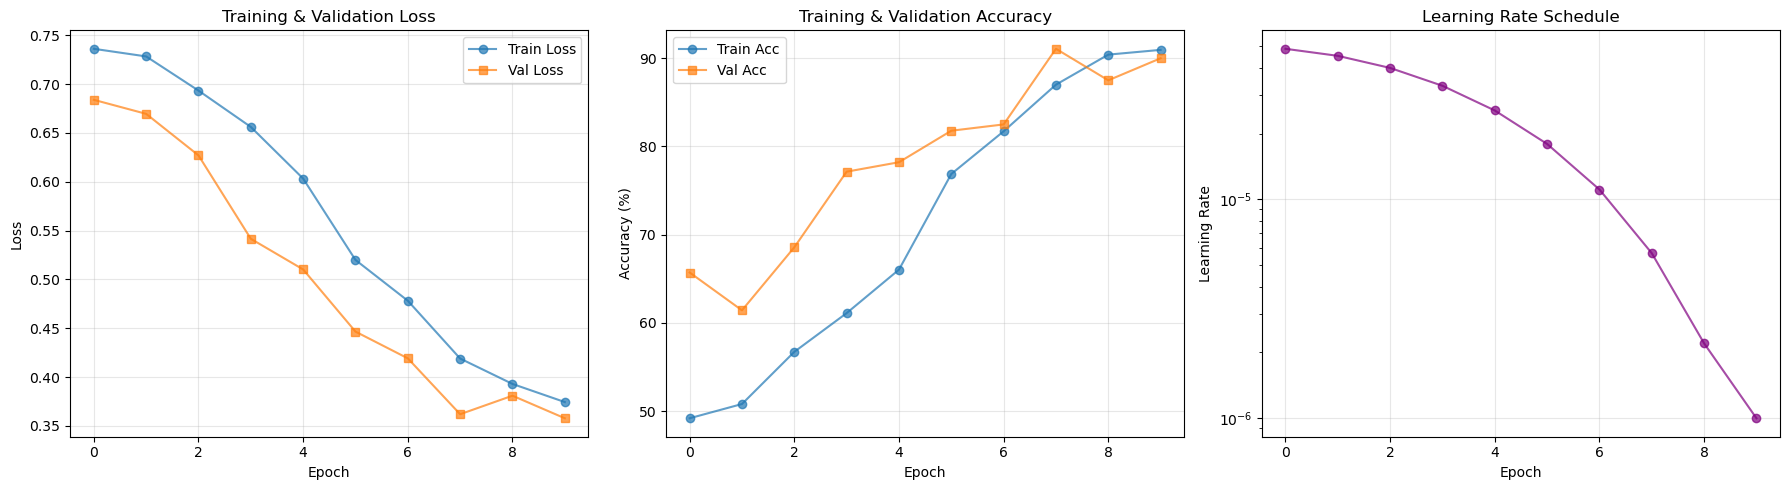

✅ Training history plot saved


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', alpha=0.7)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot([acc*100 for acc in history['train_acc']], label='Train Acc', marker='o', alpha=0.7)
axes[1].plot([acc*100 for acc in history['val_acc']], label='Val Acc', marker='s', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['learning_rates'], marker='o', alpha=0.7, color='purple')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_dir'], 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training history plot saved")

## 11. Evaluate Model

✅ Loaded best model from epoch 8


Validation: 100%|██████████| 24/24 [00:02<00:00,  8.25it/s]




 FINAL MODEL EVALUATION

📊 Performance Metrics:
  Accuracy:  91.07%
  Precision: 89.66%
  Recall:    92.86%
  F1-Score:  0.9123
  AUC-ROC:   0.9623


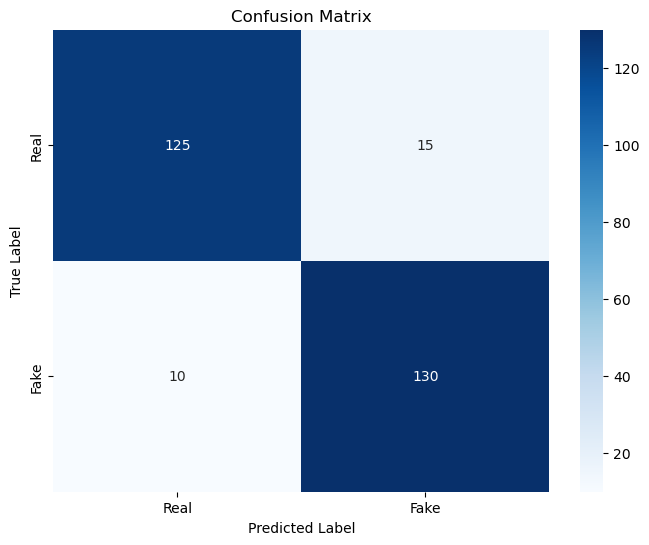


✅ Metrics saved to: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/metrics.json


In [14]:
# Load best model
checkpoint = torch.load(MODEL_CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
val_loss, val_acc, val_probs, val_labels = validate_epoch(model, val_loader, criterion, device)

# Calculate metrics
val_preds = (np.array(val_probs) > 0.5).astype(int)
val_labels_np = np.array(val_labels)

metrics = {
    'accuracy': accuracy_score(val_labels_np, val_preds),
    'precision': precision_score(val_labels_np, val_preds),
    'recall': recall_score(val_labels_np, val_preds),
    'f1_score': f1_score(val_labels_np, val_preds),
    'auc_roc': roc_auc_score(val_labels_np, val_probs)
}

print("\n" + "="*70)
print(" FINAL MODEL EVALUATION")
print("="*70)
print(f"\n📊 Performance Metrics:")
print(f"  Accuracy:  {metrics['accuracy']*100:.2f}%")
print(f"  Precision: {metrics['precision']*100:.2f}%")
print(f"  Recall:    {metrics['recall']*100:.2f}%")
print(f"  F1-Score:  {metrics['f1_score']:.4f}")
print(f"  AUC-ROC:   {metrics['auc_roc']:.4f}")

# Confusion Matrix
cm = confusion_matrix(val_labels_np, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(CONFIG['model_save_dir'], 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save metrics
with open(os.path.join(CONFIG['model_save_dir'], 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\n✅ Metrics saved to: {CONFIG['model_save_dir']}/metrics.json")
print("="*70)

## 12. Transfer Learning on New Videos

Load 200 additional videos (100 real + 100 fake) that were NOT used in initial training and fine-tune the model.

In [18]:
def load_new_videos_for_transfer_learning(real_dir, fake_dir, used_videos_tracker, 
                                          num_new_videos=100, config=None):
    """
    Load NEW videos that were NOT used in initial training.
    
    Args:
        real_dir: Directory containing real videos
        fake_dir: Directory containing fake videos
        used_videos_tracker: Path to JSON file tracking already used videos
        num_new_videos: Number of NEW videos to load per class
        config: Configuration dictionary
    
    Returns:
        sequences, labels for the new videos
    """
    print("="*70)
    print(" LOADING NEW VIDEOS FOR TRANSFER LEARNING")
    print("="*70)
    
    # Load the list of already used videos
    if os.path.exists(used_videos_tracker):
        with open(used_videos_tracker, 'r') as f:
            used_videos_data = json.load(f)
        
        used_real = set(used_videos_data['real_videos'])
        used_fake = set(used_videos_data['fake_videos'])
        
        print(f"\n📋 Previously used videos:")
        print(f"  Real: {len(used_real)} videos")
        print(f"  Fake: {len(used_fake)} videos")
    else:
        print("\n⚠️  No previous training data found!")
        print("   Creating new tracker file...")
        used_real = set()
        used_fake = set()
    
    # Get ALL available videos
    all_real_videos = sorted([os.path.join(real_dir, f) for f in os.listdir(real_dir) 
                              if f.endswith('.mp4')])
    all_fake_videos = sorted([os.path.join(fake_dir, f) for f in os.listdir(fake_dir) 
                              if f.endswith('.mp4')])
    
    print(f"\n📂 Total available videos:")
    print(f"  Real: {len(all_real_videos)} videos")
    print(f"  Fake: {len(all_fake_videos)} videos")
    
    # Filter out ALREADY USED videos
    new_real_videos = [v for v in all_real_videos if v not in used_real]
    new_fake_videos = [v for v in all_fake_videos if v not in used_fake]
    
    print(f"\n✨ NEW videos available (not used in training):")
    print(f"  Real: {len(new_real_videos)} videos")
    print(f"  Fake: {len(new_fake_videos)} videos")
    
    # Check if we have enough new videos
    if len(new_real_videos) < num_new_videos:
        print(f"\n⚠️  Warning: Only {len(new_real_videos)} new real videos available")
        print(f"   Requested: {num_new_videos}")
        num_new_videos = len(new_real_videos)
    
    if len(new_fake_videos) < num_new_videos:
        print(f"\n⚠️  Warning: Only {len(new_fake_videos)} new fake videos available")
        print(f"   Requested: {num_new_videos}")
        num_new_videos = min(num_new_videos, len(new_fake_videos))
    
    # Sample new videos
    selected_real = random.sample(new_real_videos, num_new_videos)
    selected_fake = random.sample(new_fake_videos, num_new_videos)
    
    print(f"\n🎯 Selected for transfer learning:")
    print(f"  Real: {len(selected_real)} videos")
    print(f"  Fake: {len(selected_fake)} videos")
    
    # Process the NEW videos
    print("\n🔄 Processing new videos...")
    face_extractor = FaceExtractor()
    
    all_sequences = []
    all_labels = []
    
    print("\n  Processing NEW real videos...")
    for video_path in tqdm(selected_real, desc="Real videos"):
        sequences = process_video_to_sequences(
            video_path, face_extractor,
            sequence_length=config['sequence_length'],
            max_frames=config['max_frames_per_video'],
            frame_skip=config['frame_skip']
        )
        for seq in sequences:
            all_sequences.append(seq)
            all_labels.append(0)
    
    real_seq_count = sum(1 for l in all_labels if l == 0)
    print(f"    Extracted {real_seq_count} sequences")
    
    print("\n  Processing NEW fake videos...")
    for video_path in tqdm(selected_fake, desc="Fake videos"):
        sequences = process_video_to_sequences(
            video_path, face_extractor,
            sequence_length=config['sequence_length'],
            max_frames=config['max_frames_per_video'],
            frame_skip=config['frame_skip']
        )
        for seq in sequences:
            all_sequences.append(seq)
            all_labels.append(1)
    
    fake_seq_count = sum(1 for l in all_labels if l == 1)
    print(f"    Extracted {fake_seq_count} sequences")
    
    # Balance dataset
    real_indices = [i for i, l in enumerate(all_labels) if l == 0]
    fake_indices = [i for i, l in enumerate(all_labels) if l == 1]
    
    min_sequences = min(len(real_indices), len(fake_indices))
    print(f"\n⚖️  Balancing to {min_sequences} sequences per class...")
    
    if len(real_indices) > min_sequences:
        real_indices = random.sample(real_indices, min_sequences)
    if len(fake_indices) > min_sequences:
        fake_indices = random.sample(fake_indices, min_sequences)
    
    balanced_indices = real_indices + fake_indices
    random.shuffle(balanced_indices)
    
    balanced_sequences = [all_sequences[i] for i in balanced_indices]
    balanced_labels = [all_labels[i] for i in balanced_indices]
    
    print(f"\n✅ Transfer learning dataset ready:")
    print(f"  Real sequences: {sum(1 for l in balanced_labels if l == 0)}")
    print(f"  Fake sequences: {sum(1 for l in balanced_labels if l == 1)}")
    print(f"  Total sequences: {len(balanced_sequences)}")
    
    # UPDATE the tracker to include these new videos
    updated_used_videos = {
        'real_videos': list(used_real) + selected_real,
        'fake_videos': list(used_fake) + selected_fake,
        'num_initial_videos': len(used_real),
        'num_transfer_videos': len(selected_real),
        'total_real': len(used_real) + len(selected_real),
        'total_fake': len(used_fake) + len(selected_fake)
    }
    
    with open(used_videos_tracker, 'w') as f:
        json.dump(updated_used_videos, f, indent=2)
    
    print(f"\n💾 Updated video tracker: {used_videos_tracker}")
    print(f"  Now tracking {len(updated_used_videos['real_videos'])} real videos")
    print(f"  Now tracking {len(updated_used_videos['fake_videos'])} fake videos")
    print("="*70)
    
    return balanced_sequences, balanced_labels

print("✓ Transfer learning data loading function defined")

✓ Transfer learning data loading function defined


In [19]:
# Load NEW videos for transfer learning (200 videos: 100 real + 100 fake)
# These will be DIFFERENT from the initial 100 videos used in training
transfer_sequences, transfer_labels = load_new_videos_for_transfer_learning(
    CONFIG['real_videos_dir'],
    CONFIG['fake_videos_dir'],
    CONFIG['used_videos_tracker'],
    num_new_videos=100,  # 100 NEW videos per class
    config=CONFIG
)

I0000 00:00:1760335009.700535    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5


 LOADING NEW VIDEOS FOR TRANSFER LEARNING

📋 Previously used videos:
  Real: 100 videos
  Fake: 100 videos

📂 Total available videos:
  Real: 590 videos
  Fake: 5639 videos

✨ NEW videos available (not used in training):
  Real: 490 videos
  Fake: 5539 videos

🎯 Selected for transfer learning:
  Real: 100 videos
  Fake: 100 videos

🔄 Processing new videos...

  Processing NEW real videos...


W0000 00:00:1760335009.700559    7658 gl_context_egl.cc:184] Creating a context with OpenGL ES 3 failed: UNKNOWN: ; eglChooseConfig() returned no matching EGL configuration for RGBA8888 D16 ES3 request. 
W0000 00:00:1760335009.700562    7658 gl_context_egl.cc:186] Fall back on OpenGL ES 2.
I0000 00:00:1760335009.700692    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1760335009.700696    7658 gl_context_egl.cc:184] Creating a context with OpenGL ES 3 failed: UNKNOWN: ; eglChooseConfig() returned no matching EGL configuration for RGBA8888 D16 ES3 request. 
W0000 00:00:1760335009.700697    7658 gl_context_egl.cc:186] Fall back on OpenGL ES 2.
Real videos: 100%|██████████| 100/100 [00:30<00:00,  3.25it/s]


    Extracted 700 sequences

  Processing NEW fake videos...


Fake videos: 100%|██████████| 100/100 [00:31<00:00,  3.16it/s]

    Extracted 700 sequences

⚖️  Balancing to 700 sequences per class...

✅ Transfer learning dataset ready:
  Real sequences: 700
  Fake sequences: 700
  Total sequences: 1400

💾 Updated video tracker: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/used_videos.json
  Now tracking 200 real videos
  Now tracking 200 fake videos


In [20]:
# Split transfer learning data into train and validation
transfer_train_seq, transfer_val_seq, transfer_train_labels, transfer_val_labels = train_test_split(
    transfer_sequences, transfer_labels,
    test_size=0.2,  # 80% train, 20% val
    random_state=SEED,
    stratify=transfer_labels
)

print(f"\n📊 Transfer Learning Dataset Split:")
print(f"  Training samples: {len(transfer_train_seq)}")
print(f"    - Real: {sum(1 for l in transfer_train_labels if l == 0)}")
print(f"    - Fake: {sum(1 for l in transfer_train_labels if l == 1)}")
print(f"  Validation samples: {len(transfer_val_seq)}")
print(f"    - Real: {sum(1 for l in transfer_val_labels if l == 0)}")
print(f"    - Fake: {sum(1 for l in transfer_val_labels if l == 1)}")

# Create datasets for transfer learning
transfer_train_dataset = AdvancedDeepfakeDataset(
    transfer_train_seq, transfer_train_labels,
    img_size=CONFIG['img_size'],
    augment=CONFIG['use_augmentation'],
    strong_aug=CONFIG['strong_augmentation']
)

transfer_val_dataset = AdvancedDeepfakeDataset(
    transfer_val_seq, transfer_val_labels,
    img_size=CONFIG['img_size'],
    augment=False,
    strong_aug=False
)

# Create data loaders
transfer_train_loader = DataLoader(
    transfer_train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

transfer_val_loader = DataLoader(
    transfer_val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\n✅ Transfer learning data loaders created:")
print(f"  Train batches: {len(transfer_train_loader)}")
print(f"  Validation batches: {len(transfer_val_loader)}")


📊 Transfer Learning Dataset Split:
  Training samples: 1120
    - Real: 560
    - Fake: 560
  Validation samples: 280
    - Real: 140
    - Fake: 140

✅ Transfer learning data loaders created:
  Train batches: 93
  Validation batches: 24


### Transfer Learning Configuration

We'll fine-tune the pre-trained model with:
- **Lower learning rate** (10x smaller) to avoid catastrophic forgetting
- **Fewer epochs** (5 epochs) since model is already trained
- **All layers unfrozen** for full fine-tuning on new data

In [23]:
# Load the best model from initial training
print("="*70)
print(" PREPARING FOR TRANSFER LEARNING")
print("="*70)

checkpoint = torch.load(MODEL_CHECKPOINT_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"\n✅ Loaded pre-trained model from epoch {checkpoint['epoch']+1}")
print(f"   Initial validation accuracy: {checkpoint['val_accuracy']*100:.2f}%")

# Unfreeze ALL layers for full fine-tuning
model.unfreeze_all()
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n🔓 All layers unfrozen for fine-tuning")
print(f"   Trainable parameters: {trainable_params:,}")

# Create new optimizer with LOWER learning rate for transfer learning
transfer_lr = CONFIG['learning_rate'] / 10  # 10x smaller learning rate
transfer_optimizer = optim.AdamW(
    model.parameters(),
    lr=transfer_lr,
    weight_decay=CONFIG['weight_decay']
)

# Shorter scheduler for fewer epochs
transfer_epochs = 2
transfer_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    transfer_optimizer,
    T_max=transfer_epochs,
    eta_min=CONFIG['lr_min']
)

# New scaler for mixed precision
transfer_scaler = GradScaler()

# Transfer learning history
transfer_history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'learning_rates': []
}

# Save path for transfer learning model
TRANSFER_MODEL_PATH = os.path.join(CONFIG['model_save_dir'], 'transfer_learning_model.pth')

print(f"\n⚙️  Transfer Learning Setup:")
print(f"  Learning rate: {transfer_lr:.6f} (10x smaller)")
print(f"  Epochs: {transfer_epochs}")
print(f"  Weight decay: {CONFIG['weight_decay']}")
print(f"  Training samples: {len(transfer_train_seq)}")
print(f"  Validation samples: {len(transfer_val_seq)}")
print("="*70)

 PREPARING FOR TRANSFER LEARNING

✅ Loaded pre-trained model from epoch 8
   Initial validation accuracy: 91.07%

🔓 All layers unfrozen for fine-tuning
   Trainable parameters: 50,443,585

⚙️  Transfer Learning Setup:
  Learning rate: 0.000005 (10x smaller)
  Epochs: 2
  Weight decay: 0.0005
  Training samples: 1120
  Validation samples: 280


In [24]:
# Transfer Learning Training Loop
print("\n" + "="*70)
print(" STARTING TRANSFER LEARNING")
print("="*70)
print(f"\nFine-tuning on {len(transfer_train_seq)} NEW samples")
print(f"Validating on {len(transfer_val_seq)} NEW samples")
print(f"Epochs: {transfer_epochs}")
print("="*70 + "\n")

best_transfer_val_acc = checkpoint['val_accuracy']  # Start from initial model accuracy
best_epoch = 0

for epoch in range(transfer_epochs):
    print(f"\nTransfer Learning Epoch {epoch+1}/{transfer_epochs}")
    print("-" * 50)
    
    # Train on NEW data
    train_loss, train_acc = train_epoch(
        model, transfer_train_loader, criterion, 
        transfer_optimizer, transfer_scaler, device
    )
    
    # Validate on NEW data
    val_loss, val_acc, val_probs, val_labels = validate_epoch(
        model, transfer_val_loader, criterion, device
    )
    
    # Update scheduler
    transfer_scheduler.step()
    current_lr = transfer_optimizer.param_groups[0]['lr']
    
    # Record history
    transfer_history['train_loss'].append(train_loss)
    transfer_history['train_acc'].append(train_acc)
    transfer_history['val_loss'].append(val_loss)
    transfer_history['val_acc'].append(val_acc)
    transfer_history['learning_rates'].append(current_lr)
    
    # Print summary
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%")
    print(f"  LR: {current_lr:.6f}")
    
    # Save best model
    if val_acc > best_transfer_val_acc:
        best_transfer_val_acc = val_acc
        best_epoch = epoch
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': transfer_optimizer.state_dict(),
            'scheduler_state_dict': transfer_scheduler.state_dict(),
            'val_accuracy': val_acc,
            'val_loss': val_loss,
            'transfer_history': transfer_history,
            'initial_accuracy': checkpoint['val_accuracy'],
            'config': CONFIG
        }, TRANSFER_MODEL_PATH)
        
        print(f"  ✅ New best transfer model saved! Val Acc: {val_acc*100:.2f}%")
        print(f"     Improvement over initial: {(val_acc - checkpoint['val_accuracy'])*100:+.2f}%")
    else:
        print(f"  No improvement (best: {best_transfer_val_acc*100:.2f}%)")

print("\n" + "="*70)
print(" TRANSFER LEARNING COMPLETE")
print("="*70)
print(f"\nInitial Model Accuracy: {checkpoint['val_accuracy']*100:.2f}%")
print(f"Best Transfer Learning Accuracy: {best_transfer_val_acc*100:.2f}%")
print(f"Improvement: {(best_transfer_val_acc - checkpoint['val_accuracy'])*100:+.2f}%")
print(f"\nBest model at epoch: {best_epoch+1}")
print(f"Model saved to: {TRANSFER_MODEL_PATH}")
print("="*70)


 STARTING TRANSFER LEARNING

Fine-tuning on 1120 NEW samples
Validating on 280 NEW samples
Epochs: 2


Transfer Learning Epoch 1/2
--------------------------------------------------


Validation: 100%|██████████| 24/24 [00:02<00:00,  8.17it/s]



Epoch 1 Summary:
  Train - Loss: 0.4760, Acc: 80.56%
  Val   - Loss: 0.3715, Acc: 87.50%
  LR: 0.000003
  No improvement (best: 91.07%)

Transfer Learning Epoch 2/2
--------------------------------------------------


Validation: 100%|██████████| 24/24 [00:02<00:00,  8.30it/s]



Epoch 2 Summary:
  Train - Loss: 0.3962, Acc: 89.25%
  Val   - Loss: 0.3301, Acc: 91.43%
  LR: 0.000001
  ✅ New best transfer model saved! Val Acc: 91.43%
     Improvement over initial: +0.36%

 TRANSFER LEARNING COMPLETE

Initial Model Accuracy: 91.07%
Best Transfer Learning Accuracy: 91.43%
Improvement: +0.36%

Best model at epoch: 2
Model saved to: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/transfer_learning_model.pth


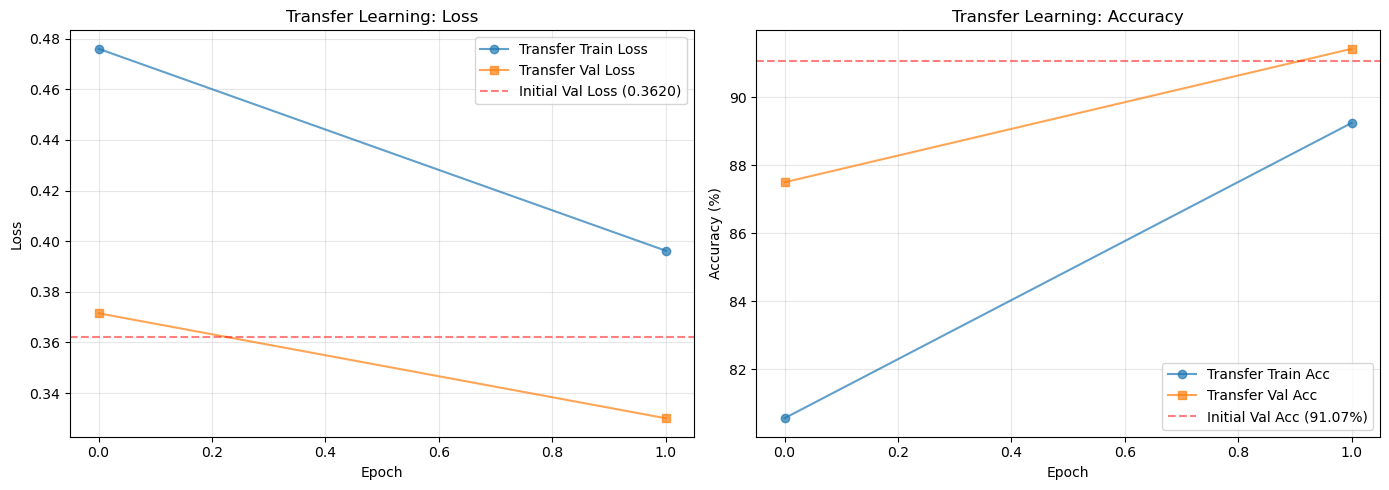

✅ Transfer learning history plot saved


In [25]:
# Visualize Transfer Learning Progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(transfer_history['train_loss'], label='Transfer Train Loss', marker='o', alpha=0.7)
axes[0].plot(transfer_history['val_loss'], label='Transfer Val Loss', marker='s', alpha=0.7)
axes[0].axhline(y=checkpoint['val_loss'], color='r', linestyle='--', 
                label=f"Initial Val Loss ({checkpoint['val_loss']:.4f})", alpha=0.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Transfer Learning: Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot([acc*100 for acc in transfer_history['train_acc']], 
             label='Transfer Train Acc', marker='o', alpha=0.7)
axes[1].plot([acc*100 for acc in transfer_history['val_acc']], 
             label='Transfer Val Acc', marker='s', alpha=0.7)
axes[1].axhline(y=checkpoint['val_accuracy']*100, color='r', linestyle='--',
                label=f"Initial Val Acc ({checkpoint['val_accuracy']*100:.2f}%)", alpha=0.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Transfer Learning: Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['model_save_dir'], 'transfer_learning_history.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Transfer learning history plot saved")

### Final Evaluation on Transfer Learning Model

Evaluate the fine-tuned model on the NEW validation set.

✅ Loaded best transfer learning model from epoch 2


Validation: 100%|██████████| 24/24 [00:02<00:00,  8.25it/s]



 TRANSFER LEARNING MODEL - FINAL EVALUATION

📊 Performance on NEW Data:
  Accuracy:  91.43%
  Precision: 94.62%
  Recall:    87.86%
  F1-Score:  0.9111
  AUC-ROC:   0.9755

📈 Comparison with Initial Model:
  Initial Validation Accuracy:  91.07%
  Transfer Learning Accuracy:   91.43%
  Improvement:                  +0.36%


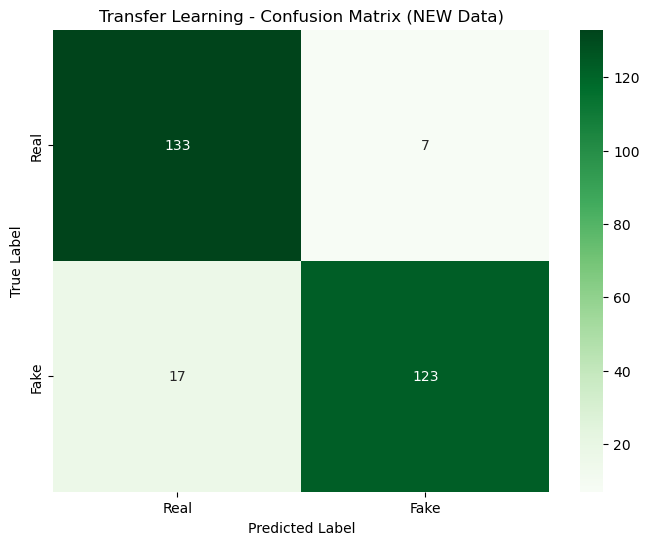


✅ Transfer learning metrics saved
✅ Model trained on 300 TOTAL videos (100 initial + 200 new)
✅ All videos tracked in: /home/nibiru/Documents/projects/cv-ai/models/Advanced_ResNet_LSTM/used_videos.json


In [26]:
# Load best transfer learning model
transfer_checkpoint = torch.load(TRANSFER_MODEL_PATH)
model.load_state_dict(transfer_checkpoint['model_state_dict'])
print(f"✅ Loaded best transfer learning model from epoch {transfer_checkpoint['epoch']+1}")

# Evaluate on NEW validation set
val_loss, val_acc, val_probs, val_labels = validate_epoch(
    model, transfer_val_loader, criterion, device
)

# Calculate metrics
val_preds = (np.array(val_probs) > 0.5).astype(int)
val_labels_np = np.array(val_labels)

transfer_metrics = {
    'accuracy': accuracy_score(val_labels_np, val_preds),
    'precision': precision_score(val_labels_np, val_preds),
    'recall': recall_score(val_labels_np, val_preds),
    'f1_score': f1_score(val_labels_np, val_preds),
    'auc_roc': roc_auc_score(val_labels_np, val_probs),
    'initial_accuracy': checkpoint['val_accuracy'],
    'improvement': accuracy_score(val_labels_np, val_preds) - checkpoint['val_accuracy']
}

print("\n" + "="*70)
print(" TRANSFER LEARNING MODEL - FINAL EVALUATION")
print("="*70)
print(f"\n📊 Performance on NEW Data:")
print(f"  Accuracy:  {transfer_metrics['accuracy']*100:.2f}%")
print(f"  Precision: {transfer_metrics['precision']*100:.2f}%")
print(f"  Recall:    {transfer_metrics['recall']*100:.2f}%")
print(f"  F1-Score:  {transfer_metrics['f1_score']:.4f}")
print(f"  AUC-ROC:   {transfer_metrics['auc_roc']:.4f}")

print(f"\n📈 Comparison with Initial Model:")
print(f"  Initial Validation Accuracy:  {checkpoint['val_accuracy']*100:.2f}%")
print(f"  Transfer Learning Accuracy:   {transfer_metrics['accuracy']*100:.2f}%")
print(f"  Improvement:                  {transfer_metrics['improvement']*100:+.2f}%")

# Confusion Matrix for Transfer Learning
cm = confusion_matrix(val_labels_np, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Transfer Learning - Confusion Matrix (NEW Data)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(CONFIG['model_save_dir'], 'transfer_confusion_matrix.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

# Save transfer learning metrics
with open(os.path.join(CONFIG['model_save_dir'], 'transfer_metrics.json'), 'w') as f:
    json.dump(transfer_metrics, f, indent=2)

print(f"\n✅ Transfer learning metrics saved")
print(f"✅ Model trained on 300 TOTAL videos (100 initial + 200 new)")
print(f"✅ All videos tracked in: {CONFIG['used_videos_tracker']}")
print("="*70)

## 13. Single Video Inference

Test the trained model on a single video file to check if it's real or fake.

In [27]:
def predict_single_video(video_path, model, config, device, use_transfer_model=True):
    """
    Predict if a single video is REAL or FAKE.
    
    Args:
        video_path: Path to the video file
        model: The trained model
        config: Configuration dictionary
        device: torch device
        use_transfer_model: If True, use transfer learning model, else use initial model
    
    Returns:
        Dictionary with prediction results
    """
    print("="*70)
    print(" SINGLE VIDEO INFERENCE")
    print("="*70)
    print(f"\n📹 Video: {os.path.basename(video_path)}")
    
    # Check if video exists
    if not os.path.exists(video_path):
        print(f"\n❌ Error: Video file not found!")
        return None
    
    # Load the appropriate model
    model_path = TRANSFER_MODEL_PATH if use_transfer_model else MODEL_CHECKPOINT_PATH
    model_name = "Transfer Learning Model" if use_transfer_model else "Initial Model"
    
    print(f"\n🔄 Loading {model_name}...")
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"✅ Model loaded from epoch {checkpoint['epoch']+1}")
    
    # Extract face sequences
    print(f"\n🔍 Processing video...")
    face_extractor = FaceExtractor()
    sequences = process_video_to_sequences(
        video_path, face_extractor,
        sequence_length=config['sequence_length'],
        max_frames=config['max_frames_per_video'],
        frame_skip=config['frame_skip']
    )
    
    if len(sequences) == 0:
        print(f"\n❌ Error: Could not extract faces from video!")
        print(f"   Possible reasons:")
        print(f"   - No faces detected in the video")
        print(f"   - Video is too short (need at least {config['sequence_length']} frames)")
        print(f"   - Face detection confidence too low")
        return None
    
    print(f"✅ Extracted {len(sequences)} sequences of {config['sequence_length']} frames each")
    
    # Prepare data
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Process all sequences
    all_probs = []
    
    print(f"\n🧠 Running inference on {len(sequences)} sequence(s)...")
    
    with torch.no_grad():
        for seq_idx, sequence in enumerate(sequences):
            # Transform frames
            transformed_frames = []
            for frame in sequence:
                frame_uint8 = np.clip(frame, 0, 255).astype(np.uint8)
                frame_tensor = transform(frame_uint8)
                transformed_frames.append(frame_tensor)
            
            sequence_tensor = torch.stack(transformed_frames).unsqueeze(0).to(device)
            
            # Get prediction
            logits, attention_weights = model(sequence_tensor)
            prob = torch.sigmoid(logits).item()
            all_probs.append(prob)
            
            print(f"  Sequence {seq_idx+1}/{len(sequences)}: {prob:.4f}")
    
    # Average probability across all sequences
    avg_prob = np.mean(all_probs)
    std_prob = np.std(all_probs)
    
    # Make final prediction
    prediction = "FAKE" if avg_prob > 0.5 else "REAL"
    confidence = avg_prob if avg_prob > 0.5 else (1 - avg_prob)
    
    # Prepare results
    results = {
        'video_path': video_path,
        'video_name': os.path.basename(video_path),
        'prediction': prediction,
        'fake_probability': avg_prob,
        'real_probability': 1 - avg_prob,
        'confidence': confidence,
        'probability_std': std_prob,
        'num_sequences': len(sequences),
        'sequence_probabilities': all_probs,
        'model_used': model_name
    }
    
    # Display results
    print("\n" + "="*70)
    print(" PREDICTION RESULTS")
    print("="*70)
    print(f"\n🎯 Prediction: {prediction}")
    print(f"📊 Confidence: {confidence*100:.2f}%")
    print(f"\n📈 Detailed Probabilities:")
    print(f"  REAL: {results['real_probability']*100:.2f}%")
    print(f"  FAKE: {results['fake_probability']*100:.2f}%")
    print(f"\n📉 Statistics:")
    print(f"  Average probability (FAKE): {avg_prob:.4f}")
    print(f"  Standard deviation: {std_prob:.4f}")
    print(f"  Number of sequences analyzed: {len(sequences)}")
    print(f"  Model used: {model_name}")
    
    # Color-coded result
    if prediction == "FAKE":
        if confidence > 0.9:
            print(f"\n🔴 HIGH CONFIDENCE FAKE ({confidence*100:.1f}%)")
        elif confidence > 0.7:
            print(f"\n🟠 MODERATE CONFIDENCE FAKE ({confidence*100:.1f}%)")
        else:
            print(f"\n🟡 LOW CONFIDENCE FAKE ({confidence*100:.1f}%)")
    else:
        if confidence > 0.9:
            print(f"\n🟢 HIGH CONFIDENCE REAL ({confidence*100:.1f}%)")
        elif confidence > 0.7:
            print(f"\n🟢 MODERATE CONFIDENCE REAL ({confidence*100:.1f}%)")
        else:
            print(f"\n🟡 LOW CONFIDENCE REAL ({confidence*100:.1f}%)")
    
    print("="*70)
    
    return results

print("✓ Single video inference function defined")

✓ Single video inference function defined


In [48]:
# ================================
# INFERENCE EXAMPLE
# ================================
# Change the path below to test any video file

# Choose which model to use
USE_TRANSFER_MODEL = True  # Set to False to use initial model only

# Specify the video path
# Examples:
#   - Real video: "/home/nibiru/Documents/projects/cv-ai/archive/Celeb-real/id0_0000.mp4"
#   - Fake video: "/home/nibiru/Documents/projects/cv-ai/archive/Celeb-synthesis/id0_id1_0000.mp4"
test_video_path = "/home/nibiru/Documents/projects/cv-ai/archive/Celeb-synthesis/id59_id61_0006.mp4"

# Run inference
results = predict_single_video(
    video_path=test_video_path,
    model=model,
    config=CONFIG,
    device=device,
    use_transfer_model=USE_TRANSFER_MODEL
)

# Store results for later analysis if needed
if results is not None:
    print(f"\n💾 Results stored in 'results' variable")
    print(f"   Access with: results['prediction'], results['confidence'], etc.")

 SINGLE VIDEO INFERENCE

📹 Video: id59_id61_0006.mp4

🔄 Loading Transfer Learning Model...
✅ Model loaded from epoch 2

🔍 Processing video...


I0000 00:00:1760336452.001080    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1760336452.001100    7658 gl_context_egl.cc:184] Creating a context with OpenGL ES 3 failed: UNKNOWN: ; eglChooseConfig() returned no matching EGL configuration for RGBA8888 D16 ES3 request. 
W0000 00:00:1760336452.001103    7658 gl_context_egl.cc:186] Fall back on OpenGL ES 2.
I0000 00:00:1760336452.001235    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1760336452.001239    7658 gl_context_egl.cc:184] Creating a context with OpenGL ES 3 failed: UNKNOWN: ; eglChooseConfig() returned no matching EGL configuration for RGBA8888 D16 ES3 request. 
W0000 00:00:1760336452.001240    7658 gl_context_egl.cc:186] Fall back on OpenGL ES 2.
W0000 00:00:1760336452.009607   54387 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


✅ Extracted 7 sequences of 10 frames each

🧠 Running inference on 7 sequence(s)...
  Sequence 1/7: 0.6913
  Sequence 2/7: 0.6077
  Sequence 3/7: 0.5660
  Sequence 4/7: 0.6131
  Sequence 5/7: 0.6453
  Sequence 6/7: 0.7398
  Sequence 7/7: 0.7930

 PREDICTION RESULTS

🎯 Prediction: FAKE
📊 Confidence: 66.52%

📈 Detailed Probabilities:
  REAL: 33.48%
  FAKE: 66.52%

📉 Statistics:
  Average probability (FAKE): 0.6652
  Standard deviation: 0.0745
  Number of sequences analyzed: 7
  Model used: Transfer Learning Model

🟡 LOW CONFIDENCE FAKE (66.5%)

💾 Results stored in 'results' variable
   Access with: results['prediction'], results['confidence'], etc.


 SAMPLE FRAMES FROM VIDEO


I0000 00:00:1760335687.589733    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1760335687.589755    7658 gl_context_egl.cc:184] Creating a context with OpenGL ES 3 failed: UNKNOWN: ; eglChooseConfig() returned no matching EGL configuration for RGBA8888 D16 ES3 request. 
W0000 00:00:1760335687.589758    7658 gl_context_egl.cc:186] Fall back on OpenGL ES 2.
I0000 00:00:1760335687.589887    7658 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1760335687.589891    7658 gl_context_egl.cc:184] Creating a context with OpenGL ES 3 failed: UNKNOWN: ; eglChooseConfig() returned no matching EGL configuration for RGBA8888 D16 ES3 request. 
W0000 00:00:1760335687.589892    7658 gl_context_egl.cc:186] Fall back on OpenGL ES 2.
W0000 00:00:1760335687.597452   20449 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


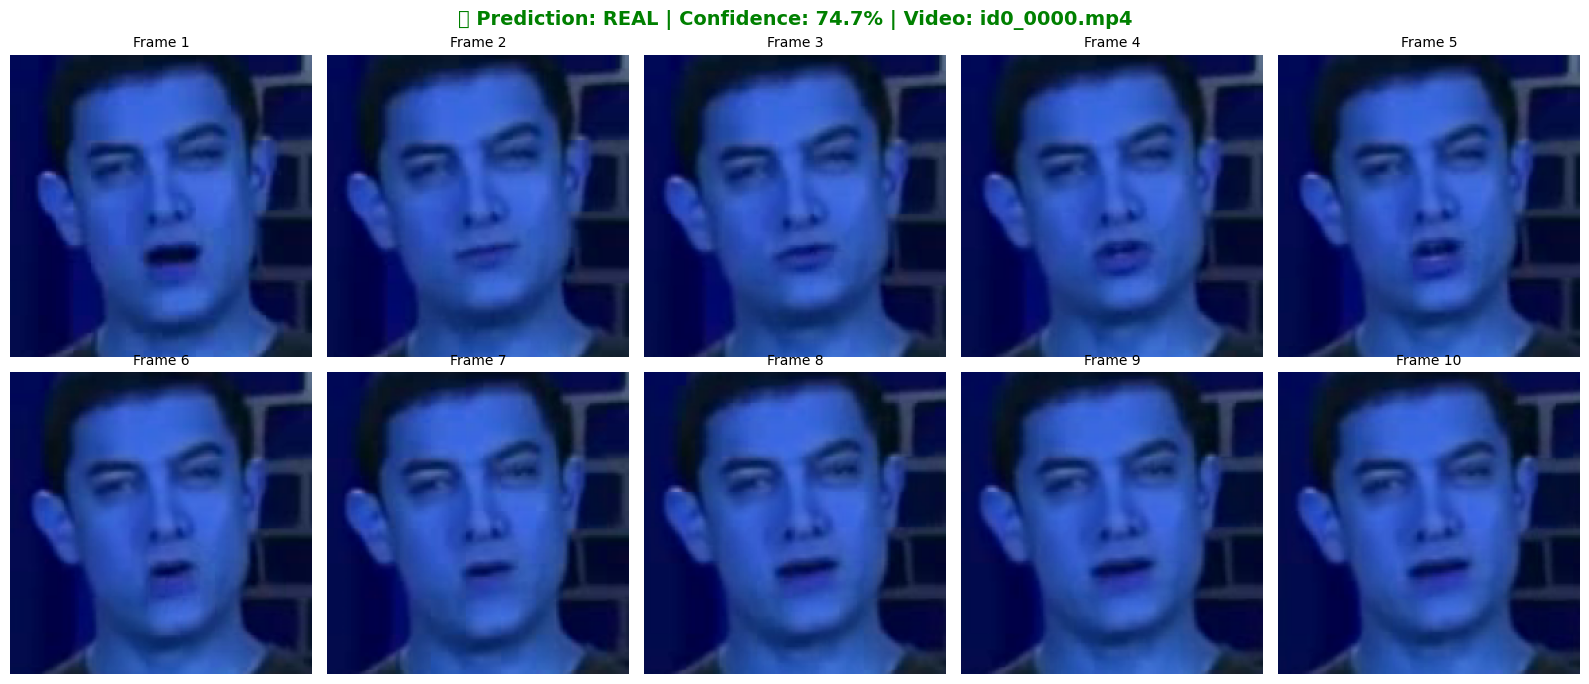


✅ Displayed 10 sample frames
   Total sequences in video: 7


In [29]:
# ================================
# VISUALIZE SAMPLE FRAMES (Optional)
# ================================
# Show sample frames from the analyzed video

if results is not None:
    print("="*70)
    print(" SAMPLE FRAMES FROM VIDEO")
    print("="*70)
    
    # Re-extract one sequence for visualization
    face_extractor = FaceExtractor()
    sequences = process_video_to_sequences(
        results['video_path'], 
        face_extractor,
        sequence_length=CONFIG['sequence_length'],
        max_frames=CONFIG['max_frames_per_video'],
        frame_skip=CONFIG['frame_skip']
    )
    
    if len(sequences) > 0:
        sample_sequence = sequences[0]  # First sequence
        
        # Create visualization
        fig, axes = plt.subplots(2, 5, figsize=(16, 7))
        prediction_label = results['prediction']
        confidence = results['confidence']
        
        # Color based on prediction
        if prediction_label == "FAKE":
            color = 'red' if confidence > 0.7 else 'orange'
            emoji = '🔴' if confidence > 0.7 else '🟠'
        else:
            color = 'green' if confidence > 0.7 else 'gold'
            emoji = '🟢' if confidence > 0.7 else '🟡'
        
        fig.suptitle(
            f'{emoji} Prediction: {prediction_label} | Confidence: {confidence*100:.1f}% | Video: {results["video_name"]}',
            fontsize=14, fontweight='bold', color=color
        )
        
        # Display frames
        for i in range(min(10, len(sample_sequence))):
            row = i // 5
            col = i % 5
            ax = axes[row, col]
            
            # Display frame (denormalize from processing)
            frame = sample_sequence[i]
            frame_uint8 = np.clip(frame, 0, 255).astype(np.uint8)
            ax.imshow(frame_uint8)
            ax.axis('off')
            ax.set_title(f'Frame {i+1}', fontsize=10)
        
        # Hide unused subplots if sequence is less than 10 frames
        for i in range(len(sample_sequence), 10):
            row = i // 5
            col = i % 5
            axes[row, col].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"\n✅ Displayed {min(10, len(sample_sequence))} sample frames")
        print(f"   Total sequences in video: {len(sequences)}")
    else:
        print("\n⚠️  Could not extract frames for visualization")
else:
    print("\n⚠️  No results to visualize. Run inference first!")